# Differentially Private Logistic Regression - Kidney Stone Risk Prediction Dataset

Using IBM `diffprivlib` across ε values.

In [1]:
import time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score
from diffprivlib.models import LogisticRegression as DPLogisticRegression
import pickle, json, os
import warnings; warnings.filterwarnings("ignore")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


In [2]:
with open("../data/processed_data.pkl","rb") as f: loaded_data = pickle.load(f)
X_train=loaded_data["X_train"]; X_test=loaded_data["X_test"]
y_train=loaded_data["y_train"]; y_test=loaded_data["y_test"]
bounds=loaded_data["bounds"]

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)
print(f"Training: {X_train.shape} | Test: {X_test.shape}")


Training: (3200, 23) | Test: (800, 23)


In [3]:
try:
    baseline_df=pd.read_csv("output/baseline_results.csv")
    baseline_accuracy=baseline_df["accuracy"].values[0]; baseline_f1=baseline_df["f1_score"].values[0]
    print(f"Baseline Accuracy: {baseline_accuracy:.4f} | F1: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: Run STD_LR.ipynb first."); baseline_accuracy=None; baseline_f1=None


Baseline Accuracy: 0.9225 | F1: 0.8924


## Single-epsilon preview (ε=1.0, 30 runs)

In [4]:
epsilon=1.0; N_RUNS=30; detail_accs=[]; detail_f1s=[]
detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed=run*10+42
    m=DPLogisticRegression(epsilon=epsilon,max_iter=1000,random_state=seed,data_norm=1.0)
    _t0 = time.perf_counter()
    m.fit(X_train,y_train)
    train_time = time.perf_counter() - _t0
    yp=m.predict(X_test)
    detail_accs.append(accuracy_score(y_test,yp)); detail_f1s.append(f1_score(y_test,yp,zero_division=0))
    detail_extra.add(y_test, yp, model=m, X=X_test, train_time=train_time)
    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {detail_accs[-1]:.4f} | F1: {detail_f1s[-1]:.4f}")
mean_acc=np.mean(detail_accs)
print(f"\nAcc: {mean_acc:.4f}\u00b1{np.std(detail_accs):.4f} | F1: {np.mean(detail_f1s):.4f}\u00b1{np.std(detail_f1s):.4f}")
if baseline_accuracy: print(f"ACL: {1-mean_acc/baseline_accuracy:.4f} ({(1-mean_acc/baseline_accuracy)*100:.2f}%)")


print("Added metrics over the detail runs:")
print(detail_extra.describe())

  Run  1/30 | Acc: 0.8462 | F1: 0.8032
  Run  2/30 | Acc: 0.8562 | F1: 0.8166
  Run  3/30 | Acc: 0.8363 | F1: 0.7877
  Run  4/30 | Acc: 0.7725 | F1: 0.7007
  Run  5/30 | Acc: 0.8275 | F1: 0.7796
  Run  6/30 | Acc: 0.7712 | F1: 0.7109
  Run  7/30 | Acc: 0.8475 | F1: 0.8013
  Run  8/30 | Acc: 0.8500 | F1: 0.8119
  Run  9/30 | Acc: 0.8213 | F1: 0.7564
  Run 10/30 | Acc: 0.8300 | F1: 0.7763
  Run 11/30 | Acc: 0.8037 | F1: 0.7439
  Run 12/30 | Acc: 0.8325 | F1: 0.7853
  Run 13/30 | Acc: 0.8788 | F1: 0.8496
  Run 14/30 | Acc: 0.7950 | F1: 0.7267
  Run 15/30 | Acc: 0.7863 | F1: 0.7316
  Run 16/30 | Acc: 0.8200 | F1: 0.7736
  Run 17/30 | Acc: 0.8525 | F1: 0.8109
  Run 18/30 | Acc: 0.8575 | F1: 0.8190
  Run 19/30 | Acc: 0.8213 | F1: 0.7719
  Run 20/30 | Acc: 0.8700 | F1: 0.8306
  Run 21/30 | Acc: 0.8250 | F1: 0.7771
  Run 22/30 | Acc: 0.8337 | F1: 0.7726
  Run 23/30 | Acc: 0.8337 | F1: 0.7912
  Run 24/30 | Acc: 0.8650 | F1: 0.8264
  Run 25/30 | Acc: 0.8063 | F1: 0.7544
  Run 26/30 | Acc: 0.8662

## Full sweep across all ε values

In [5]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
N_RUNS = 30
results_json = {"model_type":"DP Logistic Regression","dataset":"Kidney Stone Risk Prediction Dataset","n_runs_per_epsilon":N_RUNS,"epsilon_results":{}}
results = {"epsilon":[],"accuracy_mean":[],"accuracy_std":[],"f1_score_mean":[],"f1_score_std":[],"precision_mean":[],"precision_std":[],"recall_mean":[],"recall_std":[]}
print(f"Training DP Logistic Regression with {N_RUNS} runs per epsilon...")
print("="*80)
for eps in epsilon_values:
    run_accs=[]; run_f1s=[]; run_precs=[]; run_recs=[]; run_cms=[]
    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42
        m = DPLogisticRegression(epsilon=eps,max_iter=1000,random_state=seed,data_norm=1.0)
        _t0 = time.perf_counter()
        m.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        yp = m.predict(X_test)
        run_accs.append(accuracy_score(y_test,yp))
        extra.add(y_test, yp, model=m, X=X_test, train_time=train_time)
        run_f1s.append(f1_score(y_test,yp,zero_division=0))
        run_precs.append(precision_score(y_test,yp,zero_division=0))
        run_recs.append(recall_score(y_test,yp,zero_division=0))
        run_cms.append(confusion_matrix(y_test,yp).tolist())
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(m, f'output/model/dp_lr_model_eps_{eps}.pkl')
    acc_m,acc_s=np.mean(run_accs),np.std(run_accs); f1_m,f1_s=np.mean(run_f1s),np.std(run_f1s)
    prec_m,prec_s=np.mean(run_precs),np.std(run_precs); rec_m,rec_s=np.mean(run_recs),np.std(run_recs)
    results["epsilon"].append(eps); results["accuracy_mean"].append(acc_m); results["accuracy_std"].append(acc_s)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results["f1_score_mean"].append(f1_m); results["f1_score_std"].append(f1_s)
    results["precision_mean"].append(prec_m); results["precision_std"].append(prec_s)
    results["recall_mean"].append(rec_m); results["recall_std"].append(rec_s)
    results_json["epsilon_results"][str(eps)]=dict(epsilon=float(eps),n_runs=N_RUNS,accuracy_mean=acc_m,accuracy_std=acc_s,f1_mean=f1_m,f1_std=f1_s,precision_mean=prec_m,precision_std=prec_s,recall_mean=rec_m,recall_std=rec_s,per_run_accuracies=run_accs,per_run_f1s=run_f1s,per_run_precisions=run_precs,per_run_recalls=run_recs,per_run_confusion_matrices=run_cms)
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())
    print(f"\u03b5={eps:5.1f} | Acc: {acc_m:.4f}\u00b1{acc_s:.4f} | F1: {f1_m:.4f}\u00b1{f1_s:.4f} | Prec: {prec_m:.4f}\u00b1{prec_s:.4f} | Rec: {rec_m:.4f}\u00b1{rec_s:.4f}")
print("="*80); print("Training complete!")


Training DP Logistic Regression with 30 runs per epsilon...


Model successfully exported to output/model/dp_lr_model_eps_0.1.pkl
ε=  0.1 | Acc: 0.7116±0.0753 | F1: 0.6326±0.1062 | Prec: 0.6358±0.1194 | Rec: 0.6427±0.1330
Model successfully exported to output/model/dp_lr_model_eps_0.2.pkl
ε=  0.2 | Acc: 0.7621±0.0505 | F1: 0.6942±0.0680 | Prec: 0.7006±0.0761 | Rec: 0.6928±0.0837
Model successfully exported to output/model/dp_lr_model_eps_0.4.pkl


ε=  0.4 | Acc: 0.7996±0.0336 | F1: 0.7416±0.0439 | Prec: 0.7493±0.0488 | Rec: 0.7357±0.0525
Model successfully exported to output/model/dp_lr_model_eps_0.6.pkl
ε=  0.6 | Acc: 0.8198±0.0271 | F1: 0.7668±0.0360 | Prec: 0.7766±0.0376 | Rec: 0.7584±0.0443
Model successfully exported to output/model/dp_lr_model_eps_0.8.pkl


ε=  0.8 | Acc: 0.7955±0.0338 | F1: 0.7375±0.0447 | Prec: 0.7415±0.0485 | Rec: 0.7355±0.0558
Model successfully exported to output/model/dp_lr_model_eps_1.0.pkl
ε=  1.0 | Acc: 0.8315±0.0266 | F1: 0.7826±0.0353 | Prec: 0.7897±0.0352 | Rec: 0.7766±0.0438
Model successfully exported to output/model/dp_lr_model_eps_1.2.pkl


ε=  1.2 | Acc: 0.8564±0.0267 | F1: 0.8130±0.0346 | Prec: 0.8289±0.0371 | Rec: 0.7983±0.0391
Model successfully exported to output/model/dp_lr_model_eps_1.4.pkl
ε=  1.4 | Acc: 0.8750±0.0245 | F1: 0.8353±0.0317 | Prec: 0.8630±0.0367 | Rec: 0.8099±0.0344
Model successfully exported to output/model/dp_lr_model_eps_1.6.pkl


ε=  1.6 | Acc: 0.8889±0.0213 | F1: 0.8518±0.0282 | Prec: 0.8912±0.0335 | Rec: 0.8164±0.0323
Model successfully exported to output/model/dp_lr_model_eps_1.8.pkl
ε=  1.8 | Acc: 0.8982±0.0190 | F1: 0.8629±0.0256 | Prec: 0.9122±0.0316 | Rec: 0.8194±0.0308
Model successfully exported to output/model/dp_lr_model_eps_2.0.pkl


ε=  2.0 | Acc: 0.9051±0.0170 | F1: 0.8712±0.0233 | Prec: 0.9285±0.0276 | Rec: 0.8211±0.0285
Model successfully exported to output/model/dp_lr_model_eps_4.0.pkl
ε=  4.0 | Acc: 0.9197±0.0081 | F1: 0.8885±0.0121 | Prec: 0.9719±0.0095 | Rec: 0.8185±0.0186
Model successfully exported to output/model/dp_lr_model_eps_6.0.pkl


ε=  6.0 | Acc: 0.9208±0.0059 | F1: 0.8897±0.0090 | Prec: 0.9772±0.0061 | Rec: 0.8166±0.0144
Model successfully exported to output/model/dp_lr_model_eps_8.0.pkl
ε=  8.0 | Acc: 0.9214±0.0049 | F1: 0.8905±0.0075 | Prec: 0.9786±0.0046 | Rec: 0.8170±0.0120
Model successfully exported to output/model/dp_lr_model_eps_10.0.pkl


ε= 10.0 | Acc: 0.9219±0.0043 | F1: 0.8911±0.0065 | Prec: 0.9793±0.0038 | Rec: 0.8176±0.0106
Training complete!


In [6]:
results_df = pd.DataFrame(results)
if baseline_accuracy is not None:
    results_df["accuracy_loss_mean"] = baseline_accuracy - results_df["accuracy_mean"]
    results_df["accuracy_loss_pct"]  = results_df["accuracy_loss_mean"] * 100
os.makedirs("output", exist_ok=True)
with open("output/dp_lr_report.json", "w") as f: json.dump(results_json, f, indent=4)
results_df.to_csv("output/dp_results.csv", index=False)
print("Results saved to output/dp_lr_report.json")
print(results_df.to_string(index=False))


Results saved to output/dp_lr_report.json
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.711583      0.075307       0.632564      0.106165        0.635798       0.119432     0.642705    0.133019                0.699279               0.079930      0.761747     0.097761         0.001228        0.000133            0.210917          21.091667
     0.2       0.762125      0.050478       0.694216      0.068037        0.700611       0.076064     0.692758    0.083732                0.749733               0.053423      0.815274     0.057272         0.001287        0.000067            0.160375          16.037500
     0.4       0.799583      0.033635       0.741563      0.043899        0.749314       0.048804     0.735676    0.052471                0.788167     

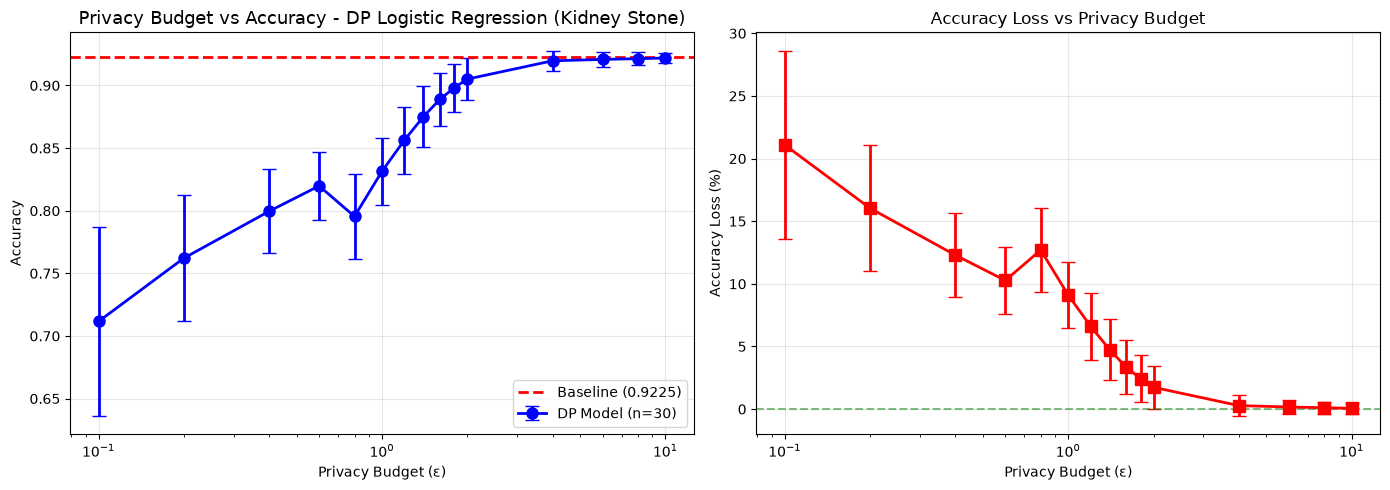

Plot saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].errorbar(results_df["epsilon"],results_df["accuracy_mean"],yerr=results_df["accuracy_std"],fmt="bo-",linewidth=2,markersize=8,capsize=5,label=f"DP Model (n={N_RUNS})")
if baseline_accuracy: axes[0].axhline(y=baseline_accuracy,color="r",linestyle="--",linewidth=2,label=f"Baseline ({baseline_accuracy:.4f})")
axes[0].set_title("Privacy Budget vs Accuracy - DP Logistic Regression (Kidney Stone)",fontsize=13)
axes[0].set_xlabel("Privacy Budget (\u03b5)"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True,alpha=0.3); axes[0].set_xscale("log")
if baseline_accuracy:
    axes[1].errorbar(results_df["epsilon"],results_df["accuracy_loss_pct"],yerr=results_df["accuracy_std"]*100,fmt="rs-",linewidth=2,markersize=8,capsize=5)
    axes[1].set_title("Accuracy Loss vs Privacy Budget"); axes[1].set_xlabel("Privacy Budget (\u03b5)"); axes[1].set_ylabel("Accuracy Loss (%)")
    axes[1].grid(True,alpha=0.3); axes[1].set_xscale("log"); axes[1].axhline(y=0,color="g",linestyle="--",alpha=0.5)
plt.tight_layout(); plt.savefig("output/privacy_accuracy_tradeoff.png",dpi=150,bbox_inches="tight")
plt.show(); print("Plot saved.")


In [8]:
print("\n"+"="*60)
print("FINAL SUMMARY")
print("="*60)
if baseline_accuracy: print(f"Baseline LR Accuracy: {baseline_accuracy:.4f}")
print(f"DP-LR Results (30 runs per epsilon):")
print(results_df.to_string(index=False))



FINAL SUMMARY
Baseline LR Accuracy: 0.9225
DP-LR Results (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.711583      0.075307       0.632564      0.106165        0.635798       0.119432     0.642705    0.133019                0.699279               0.079930      0.761747     0.097761         0.001228        0.000133            0.210917          21.091667
     0.2       0.762125      0.050478       0.694216      0.068037        0.700611       0.076064     0.692758    0.083732                0.749733               0.053423      0.815274     0.057272         0.001287        0.000067            0.160375          16.037500
     0.4       0.799583      0.033635       0.741563      0.043899        0.749314       0.048804     0.735676  